In [1]:
import pygmo as pg
import numpy as np
import os
import sys
sys.path.append("/home/jlgpke/projects/UCL/research_project/topological_insulator/notebooks/project/")
from topological_insulator import Problem
from mean_field_problem import MeanFieldProblem

In [2]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "honeycomb.json"

In [3]:
# occupations_ini = [
#     0, 0, 0.1, 0, 0.1, 0, 0.8, 0,
#     0, 0, 0, 0.1, 0, 0.1, 0, 0.8
# ]
occupations_ini = np.zeros(16)


In [4]:
mean_field_problem = MeanFieldProblem(
    structure_path, structure_name, Delta_SOC=-5,
    t=1, U=3, delta=0.83, occupations=occupations_ini
)

In [5]:
problem = Problem(
            structure_path=structure_path, structure_name=structure_name)
mean_field_problem._set_eigenvalues(problem, occupations_ini)
problem.setup(
    N_r = 10,
    N_k = 200,
    location = "bulk",
    BZ = "reduced"
)
problem.run(
    H_type="reciprocal"
)
g = problem.geometry
tb_bulk = problem.hamiltonian["bulk"]["tight_binding"]
invariants = problem.hamiltonian["bulk"]["topological_invariants"]

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


In [6]:
j_3_2 = [8, 9, 10, 11, 12, 13, 14, 15]
bands = [12, 13, 14, 15]

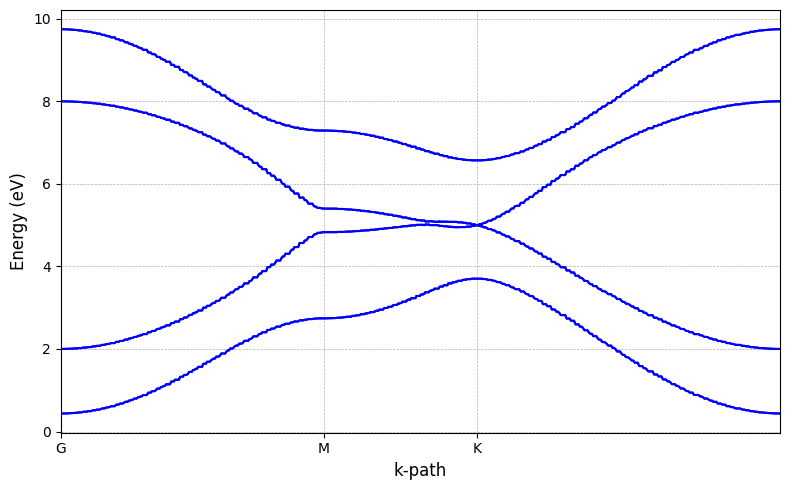

In [7]:
tb_bulk.plot_band_structure(g, j_3_2)

In [8]:
E, DOS = mean_field_problem.density_of_states(g, tb_bulk, invariants, E_max=10, E_min=1)

In [9]:
mean_field_problem.BZ_mask[0, 0] # Check for -pi, -pi point

np.False_

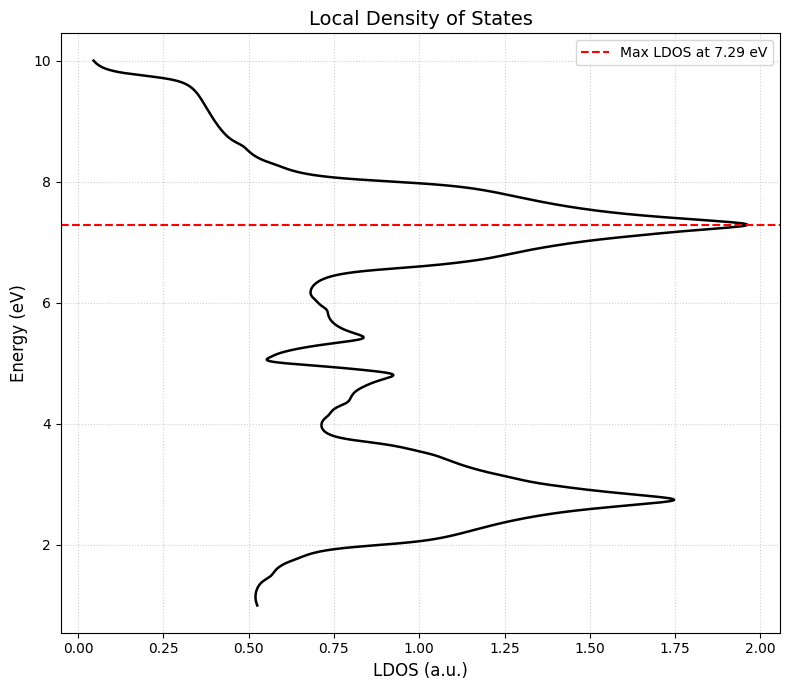

In [10]:
invariants.plot_density_of_states(E, DOS)

In [11]:
E_h = -E
# Calculate appropriate bounds based on the energy range
mu_min = np.min(E_h) - 10
mu_max = np.max(E_h) + 10

# Pass these bounds to the function
mu = mean_field_problem.find_chemical_potential(E_h, DOS, 2, 300, mu_min=mu_min, mu_max=mu_max)
print(f"mu = {mu}")

mu = 7.197280701763983


/home/jlgpke/projects/UCL/research_project/topological_insulator/notebooks/project/mean_field_problem.py:140: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp((E - mu)*beta) + 1.0)


In [12]:
occupations_new = mean_field_problem.get_occupations(g, tb_bulk, E, mu, T = 300)

In [13]:
occupations_new

array([0.00000000e+00, 0.00000000e+00, 5.07705490e-01, 5.07648412e-01,
       5.07954339e-01, 5.07736074e-01, 4.11268536e-01, 4.11133271e-01,
       2.24366107e-31, 2.16229505e-31, 5.07648412e-01, 5.07705490e-01,
       5.07736074e-01, 5.07954339e-01, 4.11133271e-01, 4.11268536e-01])

In [14]:
N_h = np.sum(occupations_new)
N_h

np.float64(5.706892244335755)

In [19]:
N_h = 2
tol = 1e-5
occupations_old  = [
    0, 0, 0.333, 0, 0.333, 0., 0.333, 0,
    0, 0, 0, 0.333, 0, 0.333, 0., 0.333
] # antiferromagnet
converged = False
counter = 0
results = {}
while not converged:
    mean_field_problem = MeanFieldProblem(
    structure_path, structure_name, Delta_SOC=-5,
    t=-1, U=1, delta=0.832, occupations=occupations_old
    )
    occupations_new, mu = mean_field_problem._objective(
        occupations=occupations_old, 
        E_max=10, 
        E_min=1, 
        eta=0.08, 
        mu_max=10, 
        mu_min=5, 
        T=300, 
        N_e=N_h
    )
    results[counter] = occupations_new
    diff = np.abs(occupations_old - occupations_new)
    print(counter, diff)
    converged = np.all(diff < tol)
    occupations_old = occupations_new
    counter +=1


Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
0 [0.00000000e+00 0.00000000e+00 1.13262901e-01 4.30778338e-01
 1.18710104e-01 4.38995000e-01 2.79125201e-01 6.16034013e-01
 1.47475229e-31 1.77737551e-31 4.26528315e-01 1.09333000e-01
 4.48865085e-01 1.24734829e-01 6.16699854e-01 2.80468598e-01]

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
1 [0.00000000e+00 0.00000000e+00 2.82629673e-03 1.92920589e-03
 6.70804457e-03 1.14446276e-03 7.13767548e-04 2.72382563e-03
 4.75751664e-32 7.38591825e-32 5.82260164e-03 3.59108357e-04
 3.95164910e-03 6.24578926e-03 5.82488945e-04 1.61615114e-03]

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
2 [0.00000000e+00 0.00000000e+00

In [16]:
occupations_new

array([0.00000000e+00, 0.00000000e+00, 3.68966669e-01, 3.26575509e-01,
       3.74178604e-01, 3.54106680e-01, 5.75092404e-01, 6.03061107e-01,
       4.90097461e-32, 5.00149777e-32, 3.39389175e-01, 3.26842287e-01,
       3.76266096e-01, 3.58251365e-01, 5.85755837e-01, 5.94176927e-01])

In [17]:
print(f"N_e = {sum(occupations_new)}, mu = {mu}")

N_e = 5.182662659257998, mu = 4.631361345916014
